In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
%matplotlib inline
from mlxtend.frequent_patterns import apriori,association_rules
from mlxtend.preprocessing import TransactionEncoder 

In [2]:
df=pd.read_excel(r"B:\New folder\Association Rules\Online retail.xlsx")
df

,"shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil"
0,"burgers,meatballs,eggs"
1,chutney
2,"turkey,avocado"
3,"mineral water,milk,energy bar,whole wheat rice..."
4,low fat yogurt
...,...
7495,"butter,light mayo,fresh bread"
7496,"burgers,frozen vegetables,eggs,french fries,ma..."
7497,chicken
7498,"escalope,green tea"


In [3]:
df.columns=['items']
df

,items
0,"burgers,meatballs,eggs"
1,chutney
2,"turkey,avocado"
3,"mineral water,milk,energy bar,whole wheat rice..."
4,low fat yogurt
...,...
7495,"butter,light mayo,fresh bread"
7496,"burgers,frozen vegetables,eggs,french fries,ma..."
7497,chicken
7498,"escalope,green tea"


Visualization

In [4]:
df.isnull().sum()

items    0
dtype: int64

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5175 entries, 0 to 7499
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   items   5175 non-null   object
dtypes: object(1)
memory usage: 80.9+ KB


<Axes: ylabel='items'>

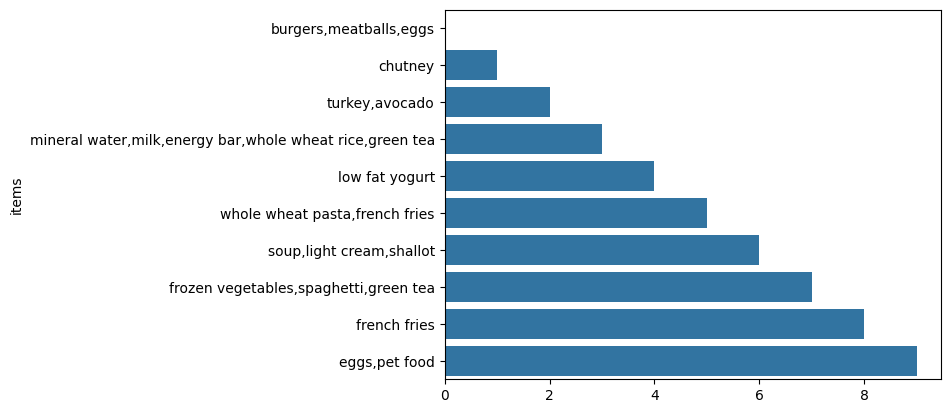

In [7]:
sb.barplot(df['items'].head(10))

there is no deffreence in the ploting histogram

(array([1., 0., 1., 0., 0., 1., 0., 1., 0., 1.]),
 array([0. , 0.4, 0.8, 1.2, 1.6, 2. , 2.4, 2.8, 3.2, 3.6, 4. ]),
 <BarContainer object of 10 artists>)

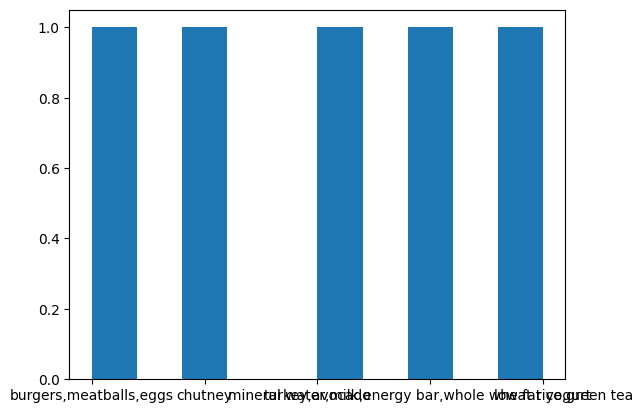

In [8]:
plt.hist(df['items'].head(5))

Pre-Processing the data

tolist() is used to convert the pandas series into the python list.

In [9]:
items=df['items'].apply(lambda x:x.split(','))
items=items.tolist()

In [10]:
trans_encoder=TransactionEncoder()
trans_data=trans_encoder.fit_transform(items)
transformed_df=pd.DataFrame(trans_data,columns=trans_encoder.columns_,dtype='int')
transformed_df

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5170,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5171,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
5172,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5173,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
frequent_itemsets=apriori(transformed_df,min_support=0.01,use_colnames=True)
frequent_itemsets

c:\Users\shyam\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:109: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.029179,(almonds)
1,0.011014,(antioxydant juice)
2,0.045797,(avocado)
3,0.012560,(bacon)
4,0.015459,(barbecue sauce)
...,...,...
431,0.014686,"(olive oil, mineral water, spaghetti)"
432,0.016618,"(pancakes, mineral water, spaghetti)"
433,0.012367,"(shrimp, mineral water, spaghetti)"
434,0.010821,"(soup, mineral water, spaghetti)"


In [12]:
rules=association_rules(frequent_itemsets,metric='lift',min_threshold=1)
rules_sort_values=rules.sort_values('lift',ascending=False)
rules_sort_values

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
424,(whole wheat pasta),(olive oil),0.040580,0.087536,0.011014,0.271429,3.100757,0.007462,1.252401,0.706154
425,(olive oil),(whole wheat pasta),0.087536,0.040580,0.011014,0.125828,3.100757,0.007462,1.097519,0.742493
796,(soup),"(milk, mineral water)",0.070918,0.067826,0.012367,0.174387,2.571089,0.007557,1.129069,0.657703
793,"(milk, mineral water)",(soup),0.067826,0.070918,0.012367,0.182336,2.571089,0.007557,1.136264,0.655521
299,(ground beef),(herb & pepper),0.135845,0.066473,0.022802,0.167852,2.525100,0.013772,1.121828,0.698921
...,...,...,...,...,...,...,...,...,...,...
151,(cookies),(eggs),0.060676,0.208116,0.012754,0.210191,1.009971,0.000126,1.002627,0.010510
647,(eggs),"(french fries, mineral water)",0.208116,0.047923,0.010048,0.048282,1.007503,0.000075,1.000378,0.009404
646,"(french fries, mineral water)",(eggs),0.047923,0.208116,0.010048,0.209677,1.007503,0.000075,1.001976,0.007822
193,(salmon),(eggs),0.057391,0.208116,0.011981,0.208754,1.003067,0.000037,1.000807,0.003244


1.	What is lift and why is it important in Association rules?

ANS:- Lift is a metric. it is used to evaluate the strength of a association rule by comparing the observed frequency. if the items are independent.

2.	What is support and Confidence. How do you calculate them?

ANS:- support measures the how frequently a particular itemset appres in the dataset.

        Confidence(A→B)= Support(A∩B)/support(A)
​

3.	What are some limitations or challenges of Association rules mining?

ANS:- Association rules mining in the context of market basket analysis or similar tasks.